In [1]:
import zipfile
import os

In [2]:
import zipfile
import os

zip_path = "/content/archive.zip"
print("Exists:", os.path.exists(zip_path))
print("Is ZIP:", zipfile.is_zipfile(zip_path))

Exists: True
Is ZIP: True


In [3]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/brain_tumor')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
# data set loading
import os

print(os.listdir('/content/brain_tumor'))


['Training', 'Testing']


In [5]:
# Load the images
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/brain_tumor/Training"
test_dir = "/content/brain_tumor/Testing"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [6]:
# cnn model code---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# train
history =cnn_model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 195ms/step - accuracy: 0.5850 - loss: 0.9583 - val_accuracy: 0.5838 - val_loss: 1.3024
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 185ms/step - accuracy: 0.7434 - loss: 0.6526 - val_accuracy: 0.6256 - val_loss: 1.3674
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 181ms/step - accuracy: 0.7709 - loss: 0.5748 - val_accuracy: 0.5100 - val_loss: 1.9395
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.8084 - loss: 0.5196 - val_accuracy: 0.7025 - val_loss: 1.2306
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.8373 - loss: 0.4461 - val_accuracy: 0.7675 - val_loss: 1.0263


In [15]:
# Evaluate the model
loss, accuracy = cnn_model.evaluate(test_generator)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7675 - loss: 1.0263
Test Loss: 1.0262668132781982
Test Accuracy: 0.7674999833106995


In [16]:
# save the model
cnn_model.save("brain_tumor_cnn_model.keras")
print("model saved successfully!")

model saved successfully!


In [17]:
# predict one mri image
import os
print(os.listdir("/content/brain_tumor/Testing"))

['notumor', 'pituitary', 'meningioma', 'glioma']


In [18]:
import os
print(os.listdir("/content/brain_tumor/Testing/glioma")[:10])

['Te-gl_204.jpg', 'Te-gl_136.jpg', 'Te-gl_232.jpg', 'Te-gl_40.jpg', 'Te-gl_289.jpg', 'Te-gl_259.jpg', 'Te-gl_178.jpg', 'Te-gl_195.jpg', 'Te-gl_8.jpg', 'Te-gl_161.jpg']


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


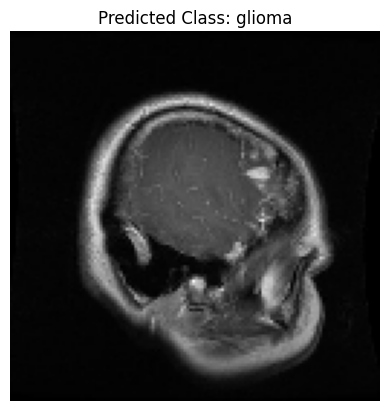

Prediction: glioma


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Change this to any image in your Testing folder
img_path = "/content/brain_tumor/Testing/glioma/Te-gl_327.jpg"

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = cnn_model.predict(img_array)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

predicted_class = classes[np.argmax(prediction)]

plt.imshow(img)
plt.title("Predicted Class: " + predicted_class)
plt.axis("off")
plt.show()

print("Prediction:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


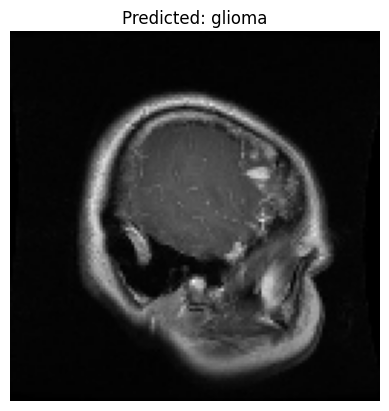

Prediction: glioma


In [21]:
#check one image file
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/brain_tumor/Testing/glioma/Te-gl_327.jpg"

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = cnn_model.predict(img_array)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

predicted_class = classes[np.argmax(prediction)]

plt.imshow(img)
plt.title("Predicted: " + predicted_class)
plt.axis("off")
plt.show()

print("Prediction:", predicted_class)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [22]:
# classification report
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = cnn_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

print("classification report:")
print(classification_report(test_generator.classes, y_pred_classes, target_names=list(test_generator.class_indices.keys())))
print("confusion matrix:")
cm=confusion_matrix(test_generator.classes, y_pred_classes)
print(cm)

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step
classification report:
              precision    recall  f1-score   support

      glioma       0.88      0.60      0.71       400
  meningioma       0.78      0.51      0.62       400
     notumor       0.64      1.00      0.78       400
   pituitary       0.86      0.96      0.91       400

    accuracy                           0.77      1600
   macro avg       0.79      0.77      0.76      1600
weighted avg       0.79      0.77      0.76      1600

confusion matrix:
[[240  48  85  27]
 [ 30 205 132  33]
 [  0   0 400   0]
 [  2  10   5 383]]


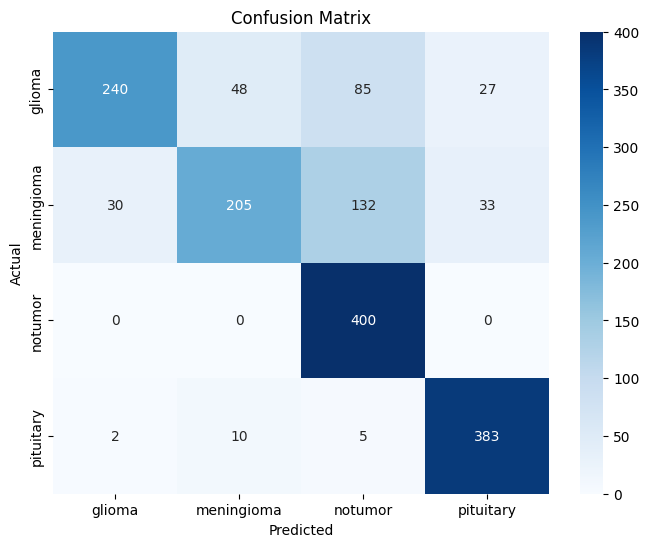

In [24]:
# confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_generator.classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()